In [32]:
# Setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Check version and if GPU available
print(f"TensorFlow version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create simple test image (32×32 with 3 color channels)
test_image = np.random.randn(1, 32, 32, 3).astype(np.float32)
test_image = (test_image - test_image.min()) / (test_image.max() - test_image.min()) # Normalize to 0-1 so image can display properly
print(f"Input shape: {test_image.shape}") # Shape format: (batch_size, height, width, channels)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Input shape: (1, 32, 32, 3)


In [33]:
# Simple convolutional layer

conv_layer = layers.Conv2D(
filters=16,         # Learn 16 different patterns
kernel_size=(3, 3), # Each filter is 3×3
strides=(1, 1),     # Move 1 pixel at a time
padding='same',     # Keep output size same as input
activation='relu',  # ReLU non-linearity
name='conv_layer_1'
)

# Apply the layer
output = conv_layer(test_image)
print(f"Output shape: {output.shape}") # 16 feature maps instead of 3 color channels

Output shape: (1, 32, 32, 16)


In [34]:
# 1x1 Convolution

# Start with 64 channels
x = layers.Conv2D(filters=64, kernel_size=3,
padding='same', activation='relu')(test_image)
print(f"After first conv: {x.shape}")

# Use 1×1 to reduce to 16 channels ("bottleneck")
x = layers.Conv2D(filters=16, kernel_size=1, activation='relu', name='bottleneck')(x)
print(f"After 1×1 bottleneck: {x.shape}") # 64 to 16 channels

# Expand back up
x = layers.Conv2D(filters=64, kernel_size=1, activation='relu', name='expand')(x)
print(f"After 1×1 expansion: {x.shape}") # 16 to 64 channels

After first conv: (1, 32, 32, 64)
After 1×1 bottleneck: (1, 32, 32, 16)
After 1×1 expansion: (1, 32, 32, 64)


In [35]:
# Conv2D Transpose (Upsampling)

# Start with a small feature map (downsampled)
small_features = layers.Conv2D(32, 3, strides=2, # Strides=2 halves spatial dimensions
                               padding='same')(test_image)
print(f"After downsampling conv: {small_features.shape}") # Spatial dimensions halved, 32×32 to 16×16

# Use Conv2DTranspose to upsample back
upsampled = layers.Conv2DTranspose(
filters=16,
kernel_size=3,
strides=2,        # Doubles spatial dimensions
padding='same',
activation='relu'
)(small_features)

print(f"After upsampling (transpose conv): {upsampled.shape}") # Back to 32×32

After downsampling conv: (1, 16, 16, 32)
After upsampling (transpose conv): (1, 32, 32, 16)


In [36]:
# Building CNN (combine all 3)

def build_simple_autoencoder():
  """
  Simple convolutional autoencoder
  Encoder: Conv -> Conv -> 1×1 bottleneck
  Decoder: 1×1 expand -> ConvTranspose -> ConvTranspose
  """
  inputs = keras.Input(shape=(32, 32, 3))

  # Encoder
  x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu', name='enc_conv1')(inputs)
  x = layers.BatchNormalization()(x)  # Add batch norm for stability

  x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu', name='enc_conv2')(x)
  x = layers.BatchNormalization()(x)

  # Bottleneck: compress to compact encoding
  encoded = layers.Conv2D(16, (1, 1), activation='relu', name='bottleneck')(x) # Compact representation: 16×16 spatial with 16 channels

  # Decoder
  # Expand channels back
  x = layers.Conv2D(64, (1, 1), activation='relu', name='expand')(encoded)
  x = layers.BatchNormalization()(x)

  # Upsample spatial dimensions
  x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu', name='dec_conv1')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu', name='dec_conv2')(x)

  # Final layer to get back to RGB
  outputs = layers.Conv2D(3, 3, padding='same', activation='sigmoid', # Add sigmoid activation as image is normalised to 0-1
                          name='output')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

# Build the model
model = build_simple_autoencoder()

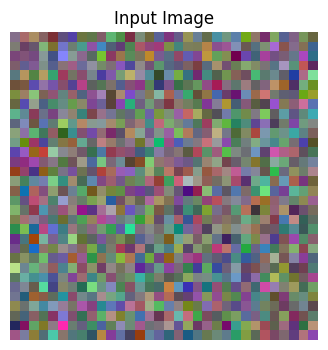

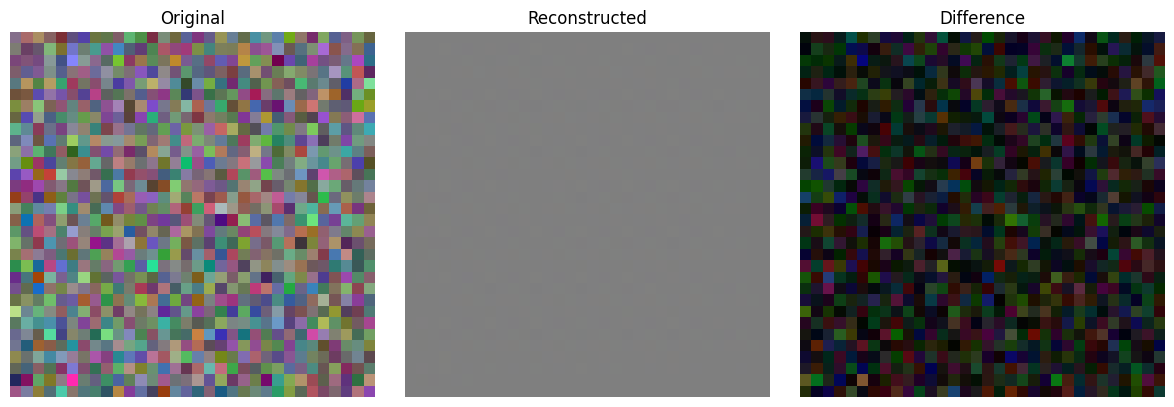

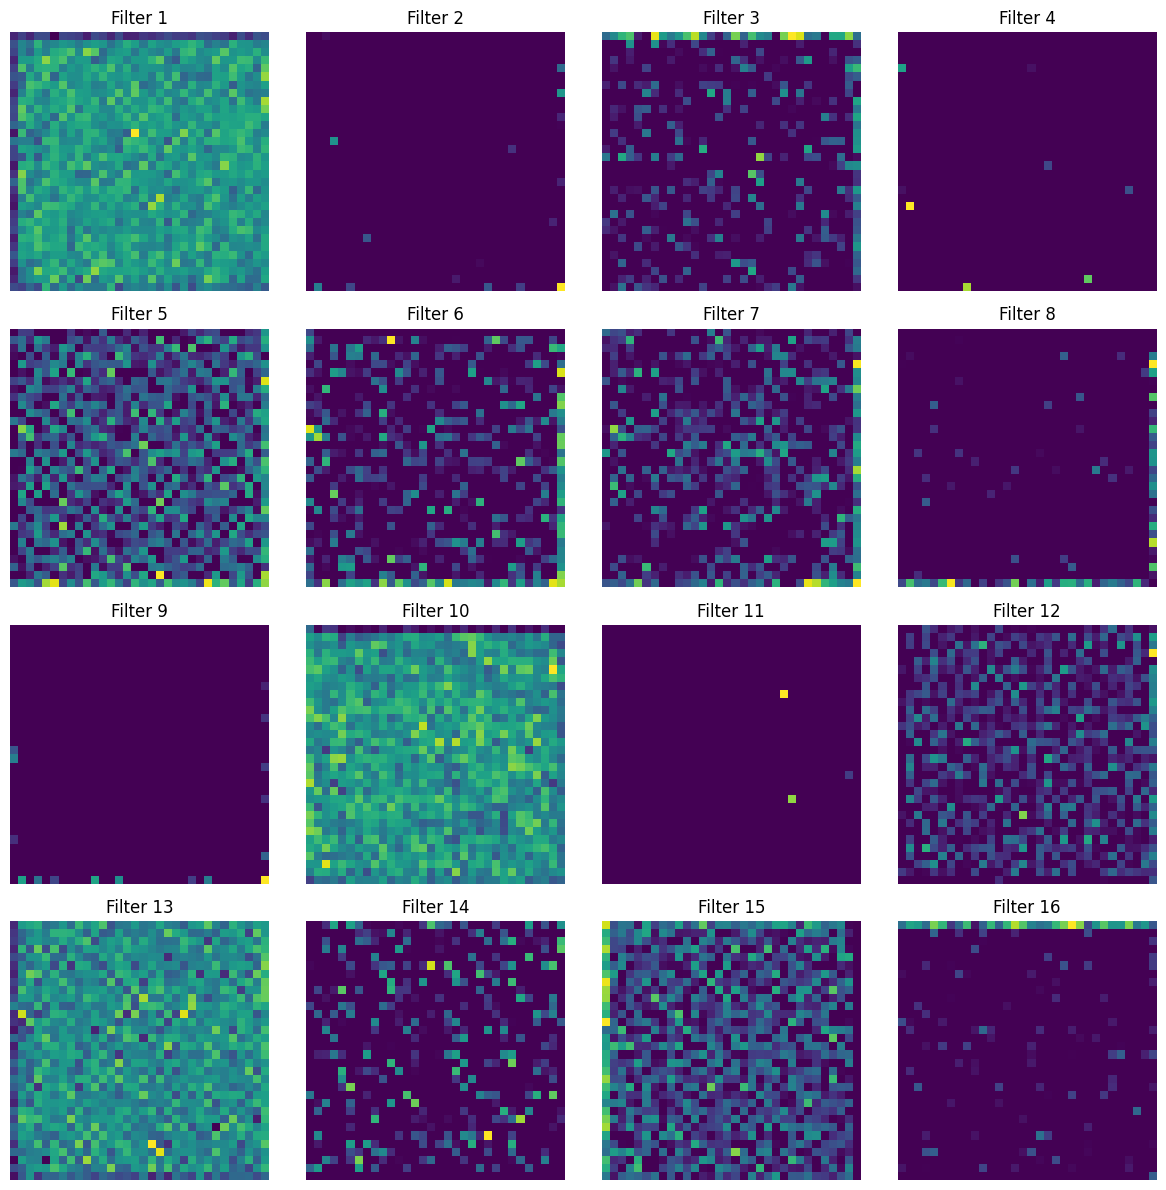

In [37]:
# Displaying images

# Display single image
plt.figure(figsize=(4, 4))
plt.imshow(test_image[0])  # Remove batch dimension
plt.title("Input Image")
plt.axis('off')
plt.show()

# Display multiple images side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_image[0])
axes[0].set_title("Original")
axes[0].axis('off')

# After passing through model
output = model(test_image)
axes[1].imshow(np.clip(output[0].numpy(), 0, 1))  # Clip to [0, 1] range
axes[1].set_title("Reconstructed")
axes[1].axis('off')

# Difference map
axes[2].imshow(np.abs(test_image[0] - output[0].numpy()), cmap='hot')
axes[2].set_title("Difference")
axes[2].axis('off')
plt.tight_layout()
plt.show()

# Feature maps (showing what filters see, run (1b) before running this for conv_layer)
conv_output = conv_layer(test_image)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < 16:  # For 16 filters
        ax.imshow(conv_output[0, :, :, i], cmap='viridis')
        ax.set_title(f'Filter {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0668 - mae: 0.2115
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0578 - mae: 0.1960
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0514 - mae: 0.1838
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0462 - mae: 0.1731
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0417 - mae: 0.1638
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0380 - mae: 0.1559
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0348 - mae: 0.1490
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0320 - mae: 0.1428
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0297 - mae: 0.1374
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0276 - mae: 0.1323
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0258 - mae: 0.1277
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0242 - mae: 0.1237
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 

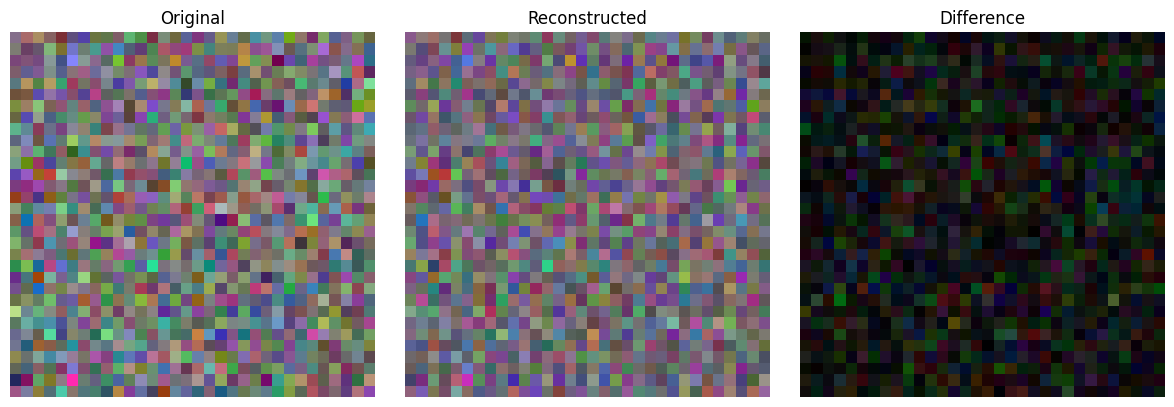

Final loss: 0.0000


In [38]:
# Training model with history

model = build_simple_autoencoder()  # Rebuild model

# Compile model (set up optimizer and loss function)

model.compile(
    optimizer='adam',  # Default learning rate = 0.001
    loss='mse',  # Mean Squared Error (good for reconstruction)
    metrics=['mae']  # Mean Absolute Error (helps track progress)
)

# Train model
# For autoencoder: input = output (it learns to reconstruct)
history = model.fit(
    test_image, test_image,  # x=input, y=target (same)
    epochs=500,              # Number of passes
    batch_size=32,           # Process 32 images at a time, only 1 image is being used though so same as 1
    verbose=1                # Show progress
)

# Display trained images
output = model(test_image)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(test_image[0])
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(np.clip(output[0].numpy(), 0, 1))
axes[1].set_title("Reconstructed")
axes[1].axis('off')

diff = np.abs(test_image[0] - output[0].numpy())
axes[2].imshow(diff, cmap='hot')
axes[2].set_title("Difference")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Final loss: {history.history['loss'][-1]:.4f}")

Training data: (60000, 32, 32, 3)
Test data: (10000, 32, 32, 3)
Training...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.1580 - mse: 0.0340 - val_loss: 0.0531 - val_mse: 0.0019
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0487 - mse: 8.4903e-04 - val_loss: 0.0475 - val_mse: 6.5180e-04
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0477 - mse: 6.1166e-04 - val_loss: 0.0471 - val_mse: 5.5618e-04
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0472 - mse: 5.0919e-04 - val_loss: 0.0470 - val_mse: 5.5941e-04
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0469 - mse: 4.4632e-04 - val_loss: 0.0468 - val_mse: 5.1323e-04
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0467 - mse: 3.9867e-04 - val_loss: 0.0464 - val_mse: 4.1076e-04
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0466 - mse: 3.5996e-04 - val_loss: 0.0463 - val_mse: 3.7966e-04
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/s

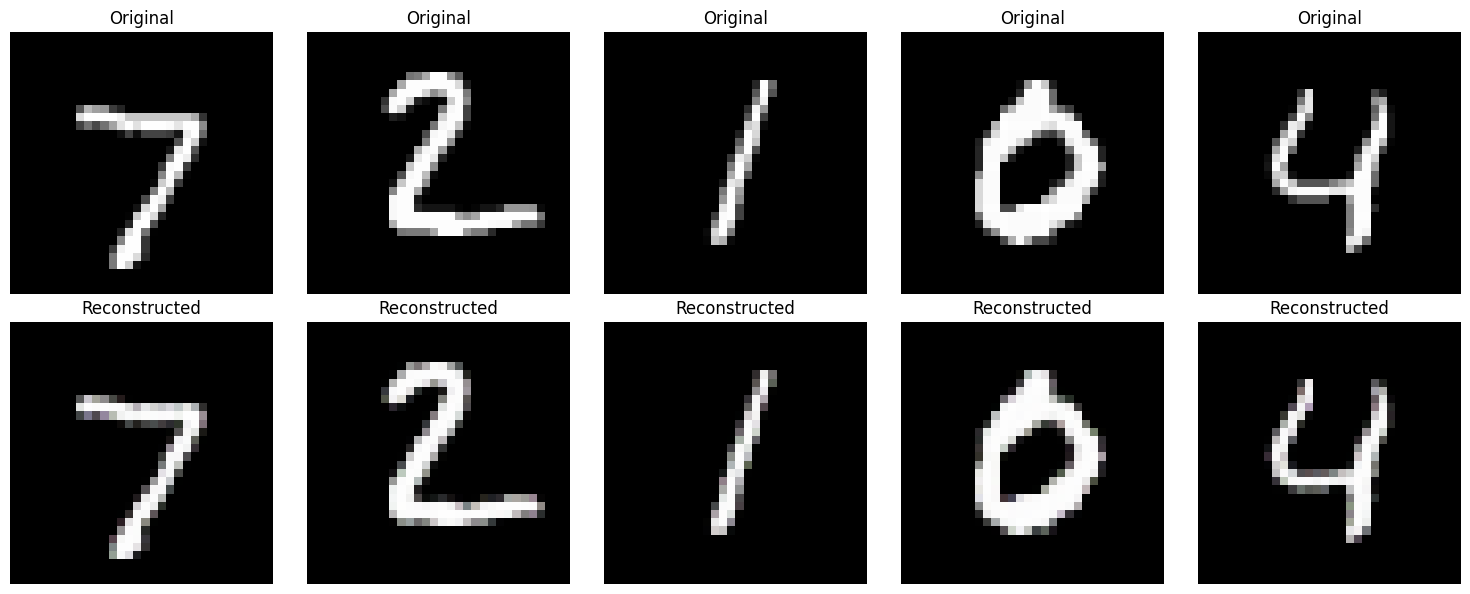

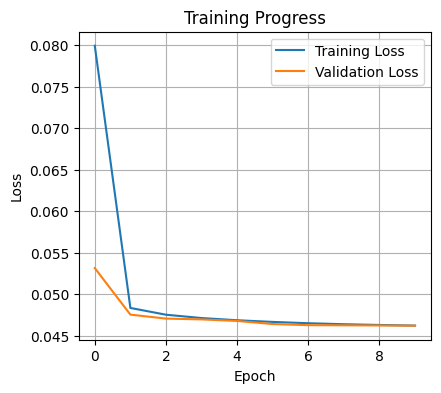

In [39]:
# Training on real data (MSINT dataset)

# Load MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Preprocess
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Pad to 32×32 and add channel dimension
x_train = np.pad(x_train, ((0,0), (2,2), (2,2)), mode='constant')
x_test = np.pad(x_test, ((0,0), (2,2), (2,2)), mode='constant')
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Repeat grayscale to 3 channels (to match model input shape)
x_train = np.repeat(x_train, 3, axis=-1)
x_test = np.repeat(x_test, 3, axis=-1)

print(f"Training data: {x_train.shape}")  # (60000, 32, 32, 3)
print(f"Test data: {x_test.shape}")       # (10000, 32, 32, 3)

# Rebuild model with fresh weights (must do if model has been already trained)
model = build_simple_autoencoder()

# Compile and train
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Better for [0,1] images
    metrics=['mse']
)

print("Training...")

history = model.fit(
    x_train, x_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, x_test),
    verbose=1
)

# Visualize results on test set
test_samples = x_test[:5]
reconstructed = model.predict(test_samples, verbose=0)

print(f"\nOutput range: [{reconstructed.min():.4f}, {reconstructed.max():.4f}]")
print(f"Output mean: {reconstructed.mean():.4f}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(test_samples[i])
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Plot loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training Progress')
plt.show()